<a href="https://colab.research.google.com/github/YamenObeidat/Activity-3--DBSCAN-PCA/blob/main/final_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EDA**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

%matplotlib inline
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('credit_card_fraud_10k.csv')
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [3]:
df_cleaned = df.drop(columns=['transaction_id'])

le = LabelEncoder()
df_cleaned['merchant_category'] = le.fit_transform(df_cleaned['merchant_category'])

df_cleaned.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,1,0,0,66,3,40,0
1,541.82,3,4,1,0,87,1,64,0
2,237.01,17,3,0,0,49,1,61,0
3,164.33,4,3,0,1,72,3,34,0
4,30.53,15,2,0,0,79,0,44,0


In [4]:
X = df_cleaned.drop(columns=['is_fraud'])
y = df_cleaned['is_fraud']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_preprocessed = pd.DataFrame(X_scaled, columns=X.columns)
X_preprocessed.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
0,-0.521597,1.503345,-0.699651,-0.329244,-0.306158,0.195528,0.691873,-0.231580
1,2.086108,-1.241383,1.420290,3.037260,-0.306158,1.172909,-0.704299,1.370727
2,0.348151,0.781048,0.713643,-0.329244,-0.306158,-0.595686,-0.704299,1.170439
3,-0.066254,-1.096923,0.713643,-0.329244,3.266284,0.474779,0.691873,-0.632157
4,-0.829151,0.492130,0.006996,-0.329244,-0.306158,0.800573,-1.402386,0.035471


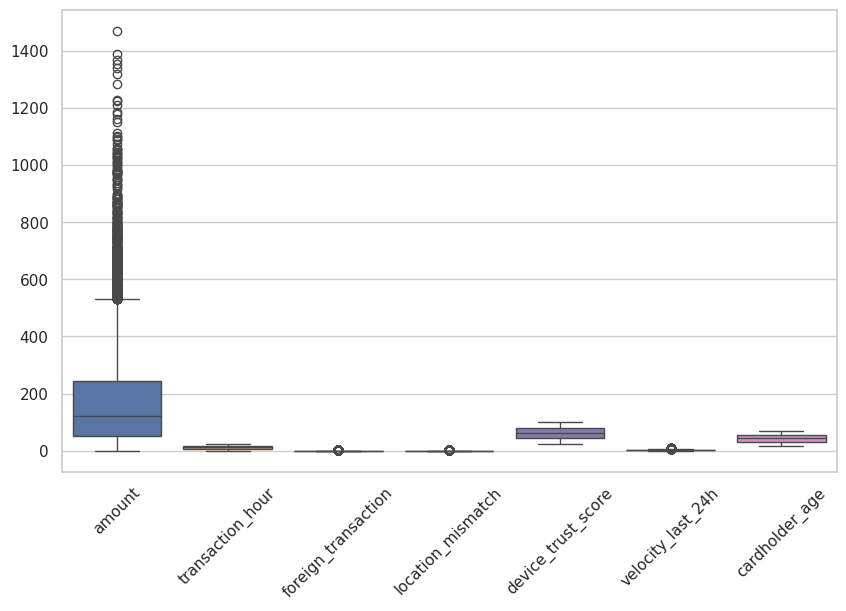

In [5]:
df.isnull().sum()
df.describe()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop(columns=['transaction_id', 'is_fraud']))
plt.xticks(rotation=45)
plt.show()

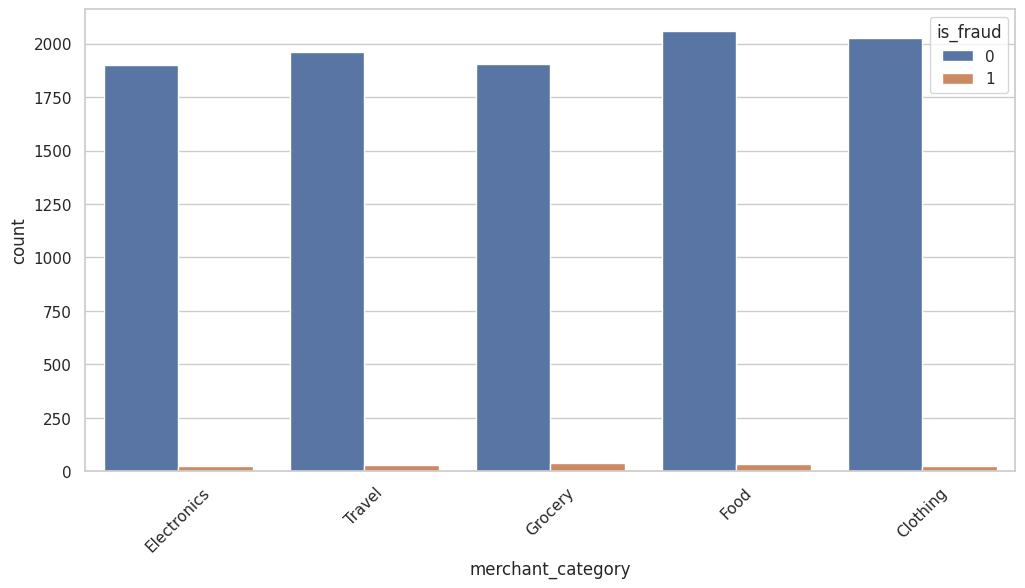

In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(x='merchant_category', hue='is_fraud', data=df)
plt.xticks(rotation=45)
plt.show()

le = LabelEncoder()
df_cleaned = df.drop(columns=['transaction_id'])
df_cleaned['merchant_category'] = le.fit_transform(df_cleaned['merchant_category'])

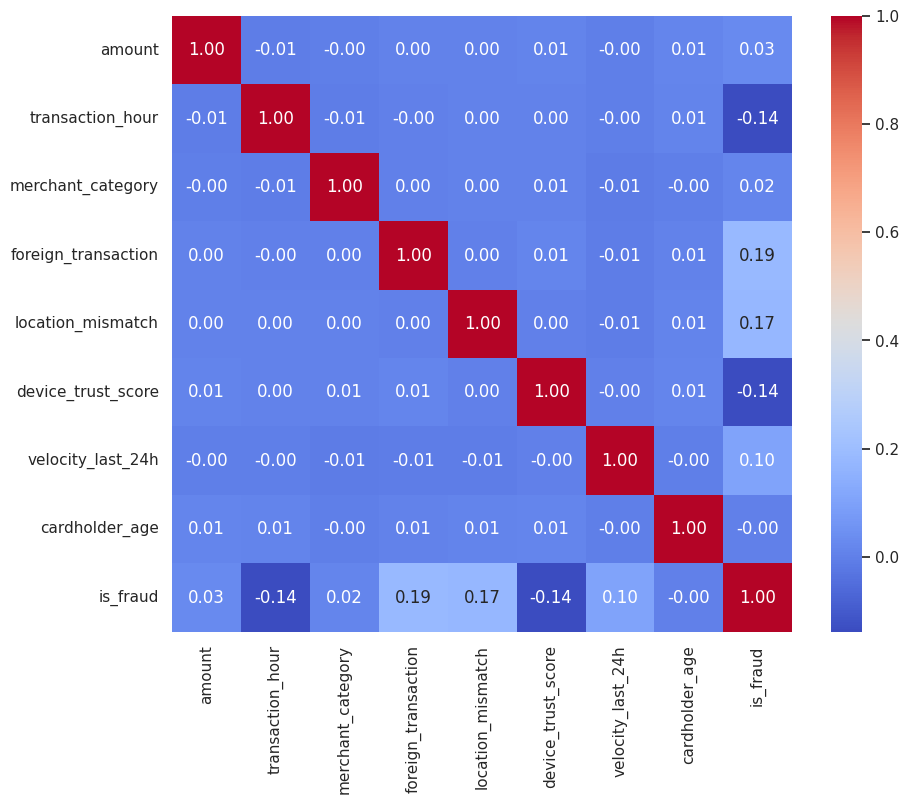

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

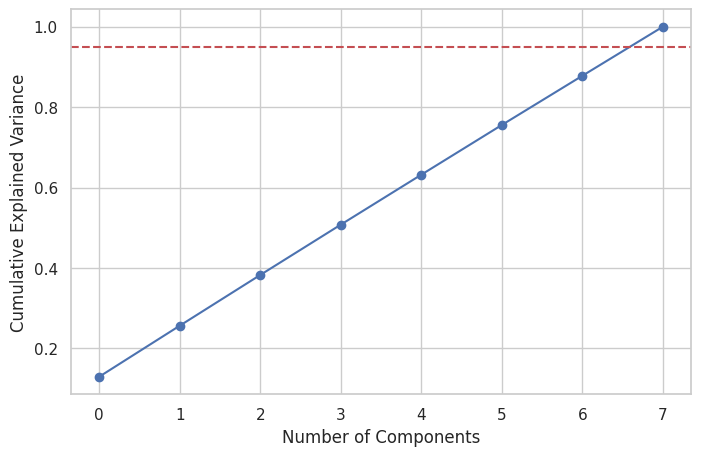

In [8]:
X = df_cleaned.drop(columns=['is_fraud'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.show()

**PCA Components experiment**

In [10]:
pca_reduced = PCA(n_components=3)

X_pca_3 = pca_reduced.fit_transform(X_scaled)

print(X_pca_3.shape)

(10000, 3)


In [11]:
total_variance_3 = np.sum(pca_reduced.explained_variance_ratio_)
print(total_variance_3)

pca_reduced.explained_variance_ratio_

0.38262286774377463


array([0.12953643, 0.12689694, 0.1261895 ])

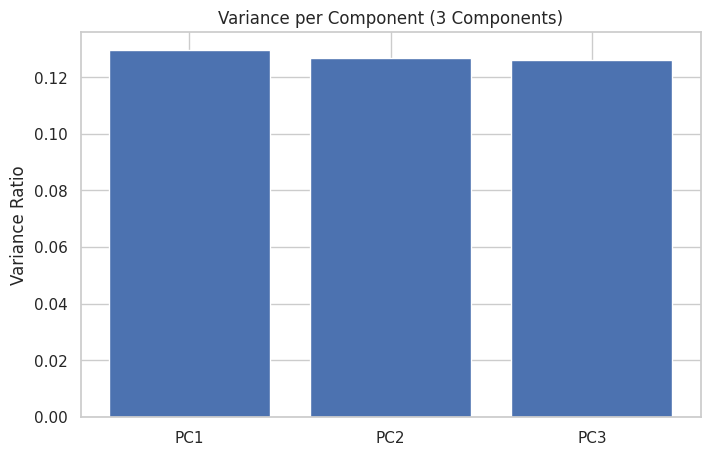

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(['PC1', 'PC2', 'PC3'], pca_reduced.explained_variance_ratio_)
plt.title('Variance per Component (3 Components)')
plt.ylabel('Variance Ratio')
plt.show()

In [13]:
pca_low = PCA(n_components=3)
X_pca_low = pca_low.fit_transform(X_scaled)
variance_retained = np.sum(pca_low.explained_variance_ratio_)
print(f"Variance Retained with 3 components: {variance_retained:.2%}")

Variance Retained with 3 components: 38.26%


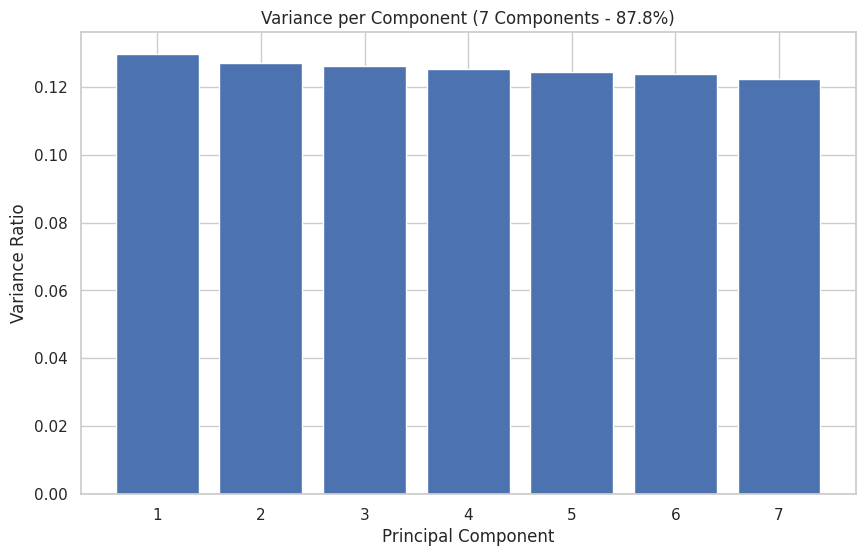

0.8780136993713322


In [16]:
pca_7 = PCA(n_components=7)
X_pca_7 = pca_7.fit_transform(X_scaled)
variance_7 = np.sum(pca_7.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.bar(range(1, 8), pca_7.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.title('Variance per Component (7 Components - 87.8%)')
plt.xticks(range(1, 8))
plt.show()

print(variance_7)

In [9]:
pca_final = PCA(n_components=0.95)
X_pca = pca_final.fit_transform(X_scaled)
print(X_pca.shape)

(10000, 8)


In [14]:
pca_final = PCA(n_components=0.95)
X_pca = pca_final.fit_transform(X_scaled)
print(f"Number of components to reach 95%: {X_pca.shape[1]}")

Number of components to reach 95%: 8


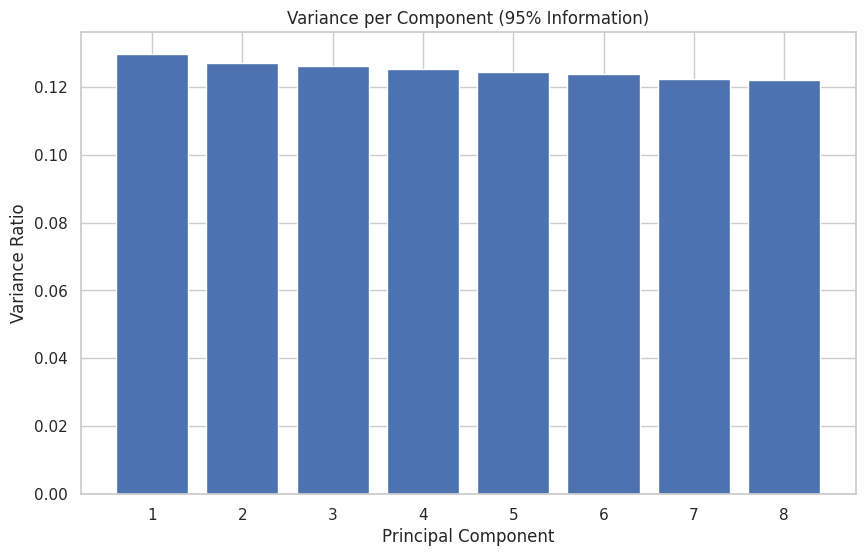

8
1.0


In [15]:
pca_final = PCA(n_components=0.95)
X_pca = pca_final.fit_transform(X_scaled)
n_comps = X_pca.shape[1]

plt.figure(figsize=(10, 6))
plt.bar(range(1, n_comps + 1), pca_final.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.title('Variance per Component (95% Information)')
plt.xticks(range(1, n_comps + 1))
plt.show()

print(n_comps)
print(np.sum(pca_final.explained_variance_ratio_))

**بالبداية جربنا نستخدم 3 مكونات (components) بس، ولقينا إنها بتغطي 38.2% من البيانات، وهذا يعني إنه ضاع علينا أكثر من نص المعلومات المهمة. بعدين جربنا 7 مكونات وحسّنا النسبة لـ 87.8%، بس لسا كان ناقصنا تفاصيل ضرورية عشان الدقة. وعشان نلتزم بمتطلبات المشروع، اعتمدنا نسبة 95%، والبرنامج لحاله اختار 8 مكونات. هذا القرار النهائي بيضمن إنّا حافظنا على كل الإشارات المهمة وشلنا الـ noise اللي ماله داعي. وهيك صار عنا أساس قوي بنقدر نعتمد عليه بالخطوات الجاية للكشف عن عمليات الاحتيال.**

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


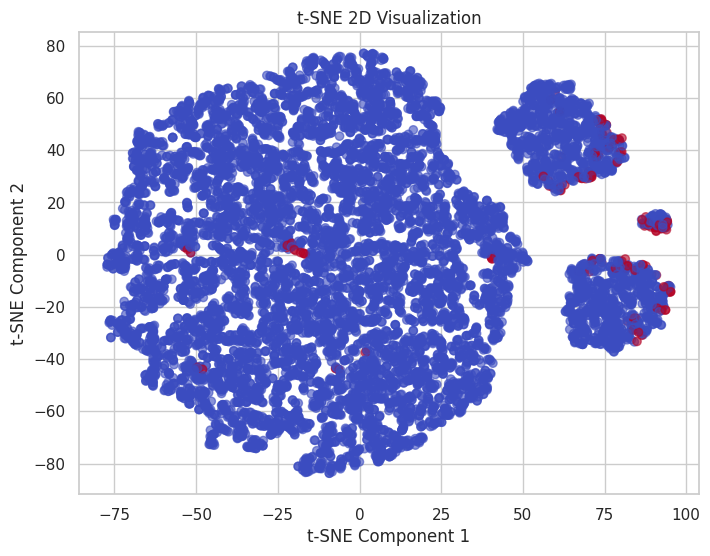

In [17]:
# Phase 3: Data Visualization with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca)  # نستخدم X_pca لتسريع العملية

# رسم وتخزين الشكل البياني
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', alpha=0.6)
ax.set_title('t-SNE 2D Visualization')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
fig.savefig('tsne_visualization.png')

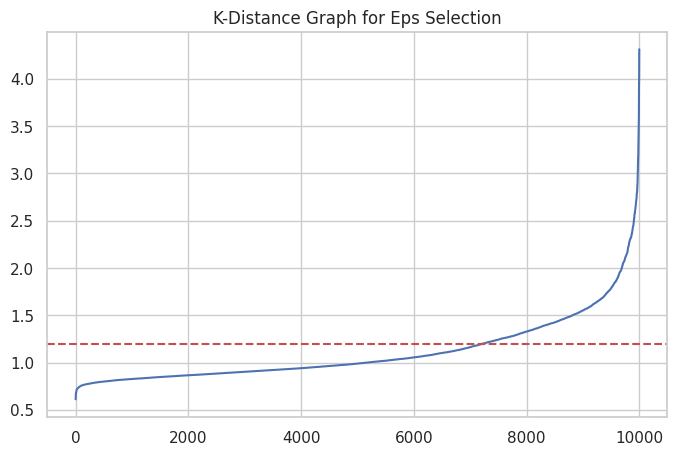

In [18]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=16)
neighbors_fit = neighbors.fit(X_pca)
distances, _ = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances[:, 15], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('K-Distance Graph for Eps Selection')
plt.axhline(y=1.2, color='r', linestyle='--')
plt.show()

In [19]:
dbscan = DBSCAN(eps=1.2, min_samples=16)
db_clusters = dbscan.fit_predict(X_pca)

df_cleaned['dbscan_cluster'] = db_clusters
print(df_cleaned['dbscan_cluster'].value_counts())

dbscan_cluster
 0     7864
-1     1576
 2      247
 1      178
 6       32
 8       19
 4       17
 10      16
 7       14
 3       14
 5       13
 9       10
Name: count, dtype: int64


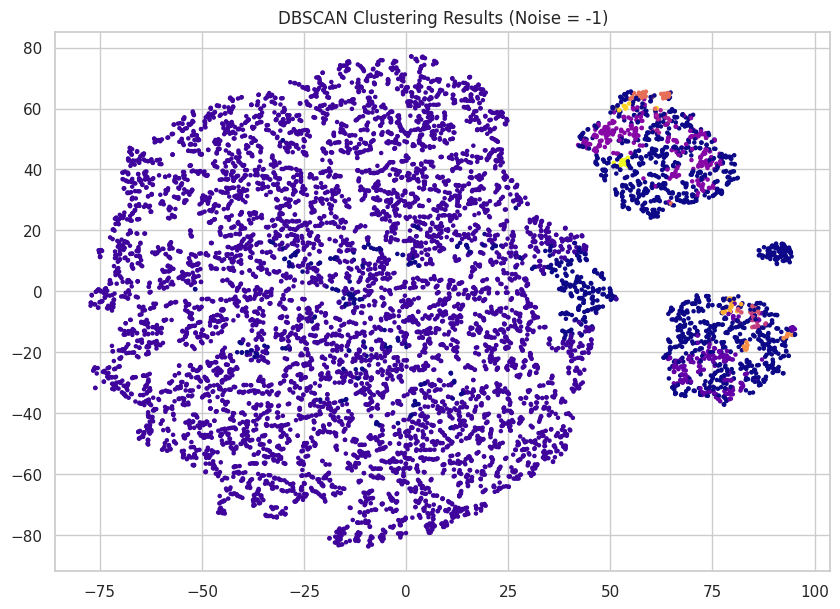

In [20]:
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=db_clusters, cmap='plasma', s=5)
plt.title('DBSCAN Clustering Results (Noise = -1)')
plt.show()

In [21]:
mask = db_clusters != -1
if len(set(db_clusters[mask])) > 1:
    s_score = silhouette_score(X_pca[mask], db_clusters[mask])
    db_index = davies_bouldin_score(X_pca[mask], db_clusters[mask])
    print(f"Silhouette Score (Excluding Noise): {s_score}")
    print(f"Davies-Bouldin Index: {db_index}")

pd.crosstab(df_cleaned['is_fraud'], df_cleaned['dbscan_cluster'])

Silhouette Score (Excluding Noise): 0.2075352386663328
Davies-Bouldin Index: 1.3579229937031707


dbscan_cluster,-1,0,1,2,3,4,5,6,7,8,9,10
is_fraud,,,,,,,,,,,,
0,1445,7853,178,240,14,17,13,32,13,18,10,16
1,131,11,0,7,0,0,0,0,1,1,0,0
